              precision    recall  f1-score   support

           0       0.82      0.74      0.77        72
           1       0.72      0.80      0.76        61

    accuracy                           0.77       133
   macro avg       0.77      0.77      0.77       133
weighted avg       0.77      0.77      0.77       133

Feature ranking:
bmi: 0.2024
s5: 0.1431
bp: 0.1346
s3: 0.1017
s2: 0.1004
s6: 0.0873
s1: 0.0823
age: 0.0796
s4: 0.0473
sex: 0.0211


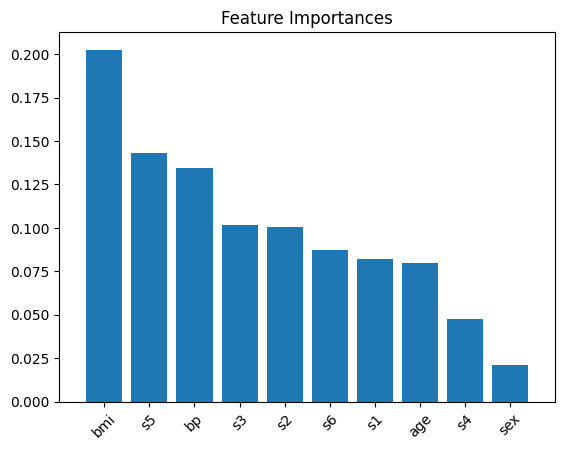

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler

diabetes = datasets.load_diabetes()
X = diabetes.data  # Features
Y = (diabetes.target > 140).astype(int)  # Binary target: 1 if diabetes, 0 otherwise

# Create a DataFrame for better visualization
diabetes_df = pd.DataFrame(data=X, columns=diabetes.feature_names)
diabetes_df['diabetes'] = Y
diabetes_df.head()

# wineds = datasets.load_wine()
# print(wineds.DESCR)
# # wineds.data
# # wineds.target

# X = wineds.data
# Y = wineds.target

X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, random_state=42, test_size=0.3)

model = RandomForestClassifier(n_estimators=100)


model.fit(X_Train, Y_Train)

predictions = model.predict(X_Test)

print(classification_report(Y_Test, predictions))


importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print feature ranking
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{diabetes.feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

# Plot the feature importances
plt.figure()
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), np.array(diabetes.feature_names)[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.show()